### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
file_path = r"C:\Users\vivil\OneDrive\Desktop\consumer_compliant\complaints_processed.csv"
df = pd.read_csv(file_path)
df.shape

(162421, 3)

In [3]:
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [5]:
df.columns

Index(['Unnamed: 0', 'product', 'narrative'], dtype='object')

In [6]:
df.isnull().sum()

Unnamed: 0     0
product        0
narrative     10
dtype: int64

In [7]:
# Drop unnecessary index column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Rename columns for clarity
df.rename(columns={
    'narrative': 'complaint',
    'product': 'category'
}, inplace=True)

df.head()


,category,complaint
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


In [8]:
#dropping null values
df.dropna(inplace=True)
df.shape

(162411, 2)

### Basic EDA

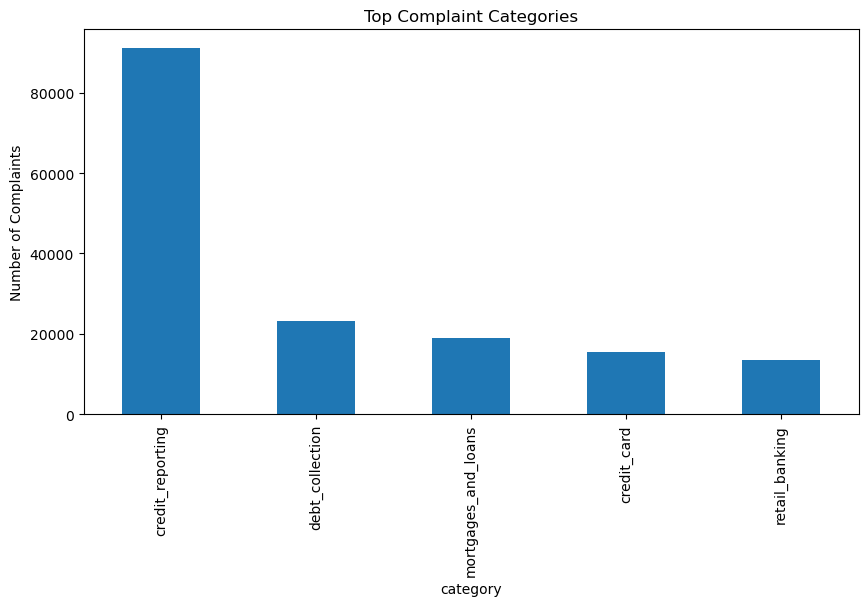

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df['category'].value_counts().head(10).plot(kind='bar')
plt.title("Top Complaint Categories")
plt.ylabel("Number of Complaints")
plt.show()

“EDA showed class imbalance, so I focused on F1-score rather than accuracy.”

### Text Preprocessing

In [10]:
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_complaint'] = df['complaint'].apply(clean_text)

df[['complaint', 'clean_complaint']].head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vivil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vivil\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,complaint,clean_complaint
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...
3,payment history missing credit report speciali...,payment history missing credit report speciali...
4,payment history missing credit report made mis...,payment history missing credit report made mis...


### Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X = df['clean_complaint']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#I used stratified sampling to preserve category distribution.

### TF-IDF Vectorization

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

TF-IDF highlights words that are important to a complaint but rare across all complaints

### Model Training

In [13]:
from sklearn.linear_model import LogisticRegression  #LR Works well with sparse text features, fast, and interpretable.

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

### Prediction & Evaluation

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))


                     precision    recall  f1-score   support

        credit_card       0.80      0.78      0.79      3113
   credit_reporting       0.91      0.94      0.92     18235
    debt_collection       0.81      0.73      0.77      4630
mortgages_and_loans       0.86      0.83      0.84      3798
     retail_banking       0.87      0.89      0.88      2707

           accuracy                           0.88     32483
          macro avg       0.85      0.83      0.84     32483
       weighted avg       0.87      0.88      0.87     32483



I focused on precision, recall, and F1-score because accuracy alone is misleading in imbalanced datasets

### Confusion matrix

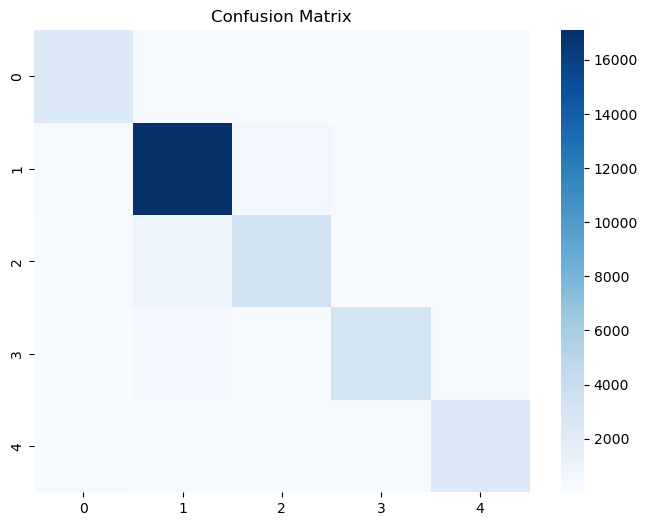

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

I built a customer complaint classification system using NLP. After cleaning and preprocessing complaint narratives, I used TF-IDF vectorization and trained a logistic regression model. The model achieved 88% accuracy and a weighted F1-score of 0.87. I evaluated performance using precision, recall, and F1-score due to class imbalance. Most errors occurred between overlapping categories like debt collection and credit reporting. This system can automate complaint routing and improve operational efficiency

### Test on Completely New Complaints

In [16]:
def predict_complaint(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    return prediction


In [17]:
test_complaints = [
    "I was charged twice for my credit card payment",
    "The debt collector keeps calling me repeatedly",
    "My mortgage interest rate suddenly increased",
    "Incorrect information is showing in my credit report",
    "My bank account transaction failed but money was debited"
]

for c in test_complaints:
    print(f"Complaint: {c}")
    print("Predicted Category:", predict_complaint(c))
    print("-" * 50)


Complaint: I was charged twice for my credit card payment
Predicted Category: credit_card
--------------------------------------------------
Complaint: The debt collector keeps calling me repeatedly
Predicted Category: debt_collection
--------------------------------------------------
Complaint: My mortgage interest rate suddenly increased
Predicted Category: mortgages_and_loans
--------------------------------------------------
Complaint: Incorrect information is showing in my credit report
Predicted Category: credit_reporting
--------------------------------------------------
Complaint: My bank account transaction failed but money was debited
Predicted Category: retail_banking
--------------------------------------------------


### Edge Case Testing

In [18]:
edge_cases = [
    "Bad service",
    "Wrong charges",                         #“Short complaints are harder to classify due to lack of context.
    "Loan issue",
    "Credit problem"
]

for c in edge_cases:
    print(c, "→", predict_complaint(c))


Bad service → credit_reporting
Wrong charges → credit_reporting
Loan issue → mortgages_and_loans
Credit problem → credit_reporting


### Robustness Testing

In [19]:
noisy_complaints = [
    "Crdit card chrgd twice!!!",             # noice handling
    "debtt collction harassment",            #“TF-IDF is moderately robust, but spelling errors affect performance.”
    "bank accnt not wrking"
]

for c in noisy_complaints:
    print(c, "→", predict_complaint(c))


Crdit card chrgd twice!!! → credit_card
debtt collction harassment → debt_collection
bank accnt not wrking → retail_banking


### Cross-validation

In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    tfidf.transform(X),
    y,
    cv=5,
    scoring='f1_weighted'
)

scores, scores.mean()


(array([0.86026593, 0.85302274, 0.85177193, 0.86702739, 0.85721893]),
 np.float64(0.8578613856102644))

Cross-validation shows consistent performance across different data splits, indicating the model is stable and not overfitting
Weighted F1 ≈ 0.86 

### Save the model

In [21]:
import joblib

joblib.dump(model, "complaint_classifier.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']